<a href="https://colab.research.google.com/github/Vane-UNCP/tecemer-lab1/blob/main/SEMANA6/Ejercicio_04d_RNN_NLP_Salud_Triaje_Clinico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4d — Redes Neuronales Recurrentes (RNN): NLP aplicado a la salud — Triaje clínico en notas médicas
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). No necesita descargar nada: genera su propio corpus de **notas clínicas sintéticas en español** (inventadas, sin datos de pacientes reales) y entrena una LSTM para decidir si una nota describe un caso que **requiere atención urgente** o **no urgente**.

**Objetivo:** recorrer el mismo flujo de NLP del Notebook 4a (tokenización, vocabulario, padding, embeddings, LSTM, evaluación), pero con los desafíos propios del **texto médico**:

| Desafío del NLP en salud | Dónde lo veremos |
|---|---|
| **Privacidad:** el texto clínico contiene datos personales | Sección 2 (de-identificación) |
| **Abreviaturas, tildes y erratas** ("HTA", "DM2", "c/", "toracico") | Sección 3 (normalización) |
| **Negación:** "niega dolor torácico" NO significa que haya dolor torácico | Secciones 9 y 11 (pares mínimos y contrafactuales) |
| **Costo asimétrico de los errores:** no detectar una urgencia es mucho peor que una falsa alarma | Secciones 7 y 10 (recall y umbral) |
| **Explicabilidad:** un clínico necesita saber *por qué* el modelo decidió | Sección 11 (oclusión y contrafactuales) |
| **Exceso de confianza ante lo desconocido:** el modelo no sabe lo que no sabe | Sección 13 (vocabulario no visto) |

Framework: **PyTorch**, igual que el 4a. Este notebook conecta con la Semana 6 (métricas: recall, precisión, umbral) y con la Semana 7 (clasificar *intents* es el mismo problema que clasificar urgencia).

> ⚠️ **Aviso importante:** este es un ejercicio **educativo**. El modelo se entrena con datos **sintéticos y simplificados** y **no debe usarse para tomar decisiones clínicas reales**. En la sección final se explica qué faltaría para llegar a un sistema real.

## 0. Configuración inicial

In [ ]:
import re
import random
import unicodedata
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score)
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
torch.manual_seed(42)
np.random.seed(42)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__, " | Dispositivo:", dispositivo)

PyTorch: 2.11.0+cu130  | Dispositivo: cuda


## 1. Generar y explorar el corpus de notas clínicas

Los textos clínicos reales (historias clínicas, notas de triaje) son **datos sensibles** y no se pueden compartir libremente. Por eso, en este ejercicio generamos notas **sintéticas** con plantillas, imitando características reales del texto médico en español:

- Datos del paciente, antecedentes y procedencia (distritos y provincias de Junín).
- **Motivo de consulta**: síntomas de alarma (clase *urgente*) o molestias leves y trámites de rutina (clase *no urgente*).
- **Negaciones** ("niega fiebre", "niega dolor torácico"), muy frecuentes en la redacción clínica.
- **Ruido real**: abreviaturas (`pte`, `HTA`, `DM2`, `c/`, `s/`), erratas y falta de tildes.

**Regla que define la etiqueta:** una nota es *urgente* si contiene un síntoma de alarma **afirmado** (no negado). Una nota que dice *"acude por tos leve, niega dolor torácico"* es **no urgente**, aunque contenga las palabras "dolor torácico".

> No es necesario leer línea por línea el código del generador: lo importante es ver sus resultados.

In [ ]:
"""Generador de notas clínicas sintéticas en español (triaje urgente / no urgente).
La etiqueta depende de si hay un síntoma de alarma AFIRMADO (no negado) en la nota."""
import random
import re
import unicodedata

# --- Conceptos: (forma corta, [formas largas para el motivo principal]) ---
URGENTES = {
    "dolor_toracico": ("dolor torácico", ["dolor torácico opresivo que se irradia al brazo izquierdo",
                                          "dolor torácico intenso con sudoración fría"]),
    "disnea": ("dificultad para respirar", ["dificultad para respirar intensa incluso en reposo",
                                            "dificultad para respirar con labios azulados"]),
    "sincope": ("pérdida de conciencia", ["pérdida súbita de la conciencia hace una hora",
                                          "pérdida de conciencia seguida de confusión"]),
    "acv": ("debilidad de un lado del cuerpo", ["debilidad de un lado del cuerpo y dificultad para hablar de inicio brusco",
                                                "debilidad de un lado del cuerpo con desviación de la boca"]),
    "convulsion": ("convulsiones", ["convulsiones de inicio reciente",
                                    "convulsiones repetidas en las últimas horas"]),
    "hematemesis": ("vómitos con sangre", ["vómitos con sangre abundante", "vómitos con sangre y mareo intenso"]),
    "hemorragia": ("hemorragia abundante", ["hemorragia abundante que no cede con presión",
                                            "hemorragia abundante tras un accidente"]),
    "meningitis": ("fiebre alta con rigidez de nuca", ["fiebre alta con rigidez de nuca y vómitos",
                                                       "fiebre alta con rigidez de nuca y somnolencia"]),
    "abdomen": ("dolor abdominal intenso", ["dolor abdominal intenso con abdomen duro como tabla",
                                            "dolor abdominal intenso que no cede y palidez"]),
    "anafilaxia": ("hinchazón de labios y lengua", ["hinchazón de labios y lengua con dificultad para respirar tras un medicamento",
                                                    "hinchazón de labios y lengua con ronchas por todo el cuerpo"]),
    "tiraje": ("tiraje subcostal", ["tiraje subcostal y respiración muy rápida",
                                    "tiraje subcostal con rechazo de alimentos"]),
}
LEVES = {
    "tos": ("tos leve", ["tos leve y congestión nasal de tres días", "tos leve con flema clara desde ayer"]),
    "garganta": ("dolor de garganta", ["dolor de garganta leve al tragar", "dolor de garganta leve y ronquera"]),
    "control_pa": ("control de presión arterial", ["control de presión arterial de rutina",
                                                   "control de presión arterial y revisión de medicación"]),
    "receta": ("renovación de receta", ["renovación de receta de su medicación habitual",
                                        "renovación de receta del tratamiento crónico"]),
    "lumbar": ("dolor lumbar", ["dolor lumbar tras cargar peso que mejora con reposo",
                                "dolor lumbar mecánico de varios días"]),
    "piel": ("picazón en la piel", ["erupción leve con picazón en la piel", "picazón en la piel sin lesiones graves"]),
    "acidez": ("acidez", ["acidez ocasional después de las comidas", "acidez y gases tras comidas copiosas"]),
    "certificado": ("certificado médico", ["solicitud de certificado médico para el trabajo",
                                           "solicitud de certificado médico escolar"]),
    "muscular": ("dolor muscular", ["dolor muscular tras actividad física", "dolor muscular leve en las piernas"]),
    "cefalea": ("cefalea leve", ["cefalea leve que cede con paracetamol", "cefalea leve al final del día"]),
    "resfrio": ("resfrío", ["resfrío tras las heladas de la semana", "resfrío con estornudos y malestar leve"]),
    "vacuna": ("control de niño sano", ["control de niño sano y vacunación", "control de niño sano con peso adecuado"]),
    "urinario": ("molestias al orinar", ["molestias leves al orinar sin otros síntomas",
                                         "molestias al orinar de dos días sin fiebre"]),
    "estrenimiento": ("estreñimiento", ["estreñimiento de varios días sin dolor intenso",
                                        "estreñimiento leve que mejora con fibra"]),
}
# Síntomas "neutros" que se pueden negar sin cambiar la urgencia
NEUTROS_NEGABLES = ["fiebre", "náuseas", "diarrea", "mareos", "tos", "dolor de cabeza"]

ANTECEDENTES = ["", "", "con antecedente de hipertensión arterial", "con diabetes mellitus tipo 2",
                "con asma", "con antecedente de cardiopatía", "sin antecedentes de importancia",
                "con antecedente de gastritis"]
PROCEDENCIAS = ["Huancayo", "El Tambo", "Chilca", "Concepción", "Jauja", "Sicaya"]
APERTURAS = ["Acude por", "Refiere", "Consulta por", "Viene por", "Presenta"]
EXTRAS = ["", "", "Se le nota cansado.", "Está acompañado por un familiar.", "Tiene buen apetito.",
          "Duerme con normalidad.", "Estado de ánimo conservado.", "No ha tomado medicación previa."]

ABREVIATURAS = {"paciente": "pte", "hipertensión arterial": "HTA", "diabetes mellitus tipo 2": "DM2",
                " con ": " c/ ", " sin ": " s/ "}


def _ruido(texto, r):
    if r.random() < 0.35:
        for largo, corto in ABREVIATURAS.items():
            if largo in texto and r.random() < 0.7:
                texto = texto.replace(largo, corto)
    palabras = texto.split()
    for i, p in enumerate(palabras):
        if len(p) > 4 and r.random() < 0.03:           # errata: se pierde una letra
            j = r.randrange(1, len(p) - 1)
            palabras[i] = p[:j] + p[j + 1:]
    texto = " ".join(palabras)
    if r.random() < 0.3:                                # sin tildes
        texto = "".join(c for c in unicodedata.normalize("NFD", texto) if unicodedata.category(c) != "Mn")
    if r.random() < 0.15:
        texto = texto.lower()
    return texto


def _negaciones(r, motivo):
    """Frase tipo 'Niega fiebre y niega dolor torácico opresivo.' (nunca niega algo que aparece en el motivo)."""
    pool = list(NEUTROS_NEGABLES)
    for corto, largos in URGENTES.values():
        if corto not in motivo:
            pool.append(r.choice([corto] + largos))       # a veces se niega la forma larga y descriptiva
    pool = [p for p in pool if not (p == "tos" and "tos" in motivo)]
    n = r.choice([0, 1, 1, 2, 2, 3])
    if n == 0:
        return ""
    elegidos = r.sample(pool, k=n)
    return "Niega " + " y niega ".join(elegidos) + "."


def generar_nota(r, urgente):
    sexo = r.choice(["masculino", "femenino"])
    edad = r.choice([r.randint(1, 10), r.randint(18, 85), r.randint(18, 85)])
    antecedente = r.choice(ANTECEDENTES)
    sujeto = f"Paciente {sexo} de {edad} años {antecedente}".strip()
    sujeto += f", procedente de {r.choice(PROCEDENCIAS)}."
    if urgente:
        clave = r.choice(list(URGENTES))
        corto, largos = URGENTES[clave]
        motivo = r.choice([corto, corto] + largos)
        negacion = _negaciones(r, motivo)
    else:
        clave = r.choice(list(LEVES))
        corto, largos = LEVES[clave]
        motivo = r.choice([corto, corto] + largos)
        negacion = _negaciones(r, motivo)
    apertura = f"{r.choice(APERTURAS)} {motivo}."
    # Molestia leve adicional (afirmada): aparece en ambas clases, así que NO sirve de atajo
    adicional = ""
    if r.random() < (0.5 if urgente else 0.3):
        otra = r.choice([c for k, (c, _) in LEVES.items() if c not in motivo])
        adicional = f"{r.choice(['Además refiere', 'También presenta', 'Asociado a'])} {otra}."
    partes = [sujeto, apertura, adicional, negacion, r.choice(EXTRAS)]
    if r.random() < 0.25:                                # a veces la negación va antes del motivo
        partes[1], partes[3] = partes[3], partes[1]
    nota = " ".join(p for p in partes if p)
    return _ruido(nota, r)


def generar_dataset(n, prop_urgentes=0.4, semilla=0):
    r = random.Random(semilla)
    textos, etiquetas = [], []
    for _ in range(n):
        u = 1 if r.random() < prop_urgentes else 0
        textos.append(generar_nota(r, bool(u)))
        etiquetas.append(u)
    return textos, etiquetas


In [ ]:
textos_train, etiquetas_train = generar_dataset(4000, prop_urgentes=0.4, semilla=1)
textos_test, etiquetas_test = generar_dataset(1000, prop_urgentes=0.4, semilla=2)

print(f"Entrenamiento: {len(textos_train)} notas | Prueba: {len(textos_test)} notas\n")
for clase, nombre in [(1, "URGENTE"), (0, "NO URGENTE")]:
    print(f"--- Ejemplos de nota {nombre} ---")
    ejemplos = [t for t, e in zip(textos_train, etiquetas_train) if e == clase][:3]
    for t in ejemplos:
        print(" •", t)
    print()

Entrenamiento: 4000 notas | Prueba: 1000 notas

--- Ejemplos de nota URGENTE ---
 • Paciente masculino de 33 anos con anteedente de gastritis, procedente de Sicaya. Consulta por hemorragia abundante. Asociado a tos leve. Niega dificultad para respirar intensa incluso en reposo y niega debilidad de un lado del cuerpo y dificultad para hablar de inicio brusco y niega nauseas.
 • Paciente masculino de 34 anos c/ DM2, procedente de Concepcion. Presenta dolor toracico intenso c/ sudoracion fia. Duerme c/ normalidad.
 • Paciente femenino de 39 anos con antecedente de hipertension arterial, procedente de Sicaya. Acude por convulsiones de inicio reciente. Asociado a control de nino sano. Niega dolor toracico opresivo que se irradia al brazo izquierdo y niega tos. Esta acompanado por un familiar.

--- Ejemplos de nota NO URGENTE ---
 • Paciente femenino de 10 años sin antecedentes de importancia, procedente de Concpción. Viene por resfrío. Niega tiraje subcostal.
 • Paciente femenino de 50 años

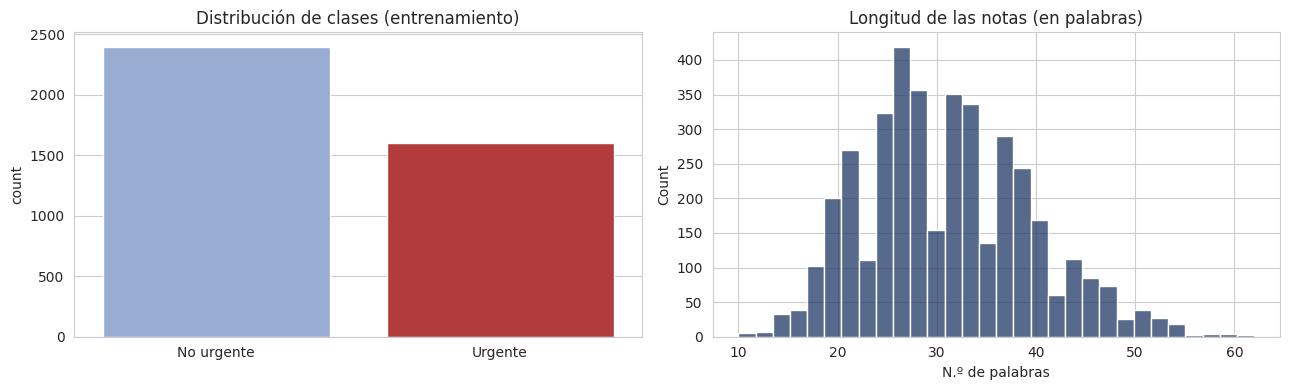

Proporción de casos urgentes: 40%
Longitud promedio: 31 palabras | Máxima: 62


In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))

nombres_clase = ["Urgente" if e == 1 else "No urgente" for e in etiquetas_train]
sns.countplot(x=nombres_clase, order=["No urgente", "Urgente"], ax=ejes[0],
              hue=nombres_clase, hue_order=["No urgente", "Urgente"],
              palette=["#8FAADC", "#C62828"], legend=False)
ejes[0].set_title("Distribución de clases (entrenamiento)")

longitudes = [len(t.split()) for t in textos_train]
sns.histplot(longitudes, bins=30, ax=ejes[1], color="#1F3864")
ejes[1].set_title("Longitud de las notas (en palabras)")
ejes[1].set_xlabel("N.º de palabras")
plt.tight_layout()
plt.show()

print(f"Proporción de casos urgentes: {np.mean(etiquetas_train):.0%}")
print(f"Longitud promedio: {np.mean(longitudes):.0f} palabras | Máxima: {np.max(longitudes)}")

**Lectura:** las clases están **desbalanceadas** (menos urgencias que consultas de rutina), como ocurre en la práctica. Recordemos de la Semana 6 que, con clases desbalanceadas, la *accuracy* sola puede engañar: en este caso, un modelo que dijera "no urgente" siempre acertaría ~60 % de las veces y no detectaría **ninguna** urgencia.

## 2. Privacidad primero: de-identificación del texto clínico

Antes de usar texto clínico real en cualquier modelo, hay que **quitar los datos que identifican a la persona** (nombre, DNI, teléfono, correo, fechas, número de historia clínica). En el Perú, los datos de salud son **datos sensibles** protegidos por la **Ley N.º 29733 (Protección de Datos Personales)**.

Una primera línea de defensa son las **expresiones regulares** para identificadores con formato fijo. (Todos los datos de este ejemplo son inventados.)

In [ ]:
PATRONES_PRIVACIDAD = [
    (r"(?<=Paciente: )(?:[A-ZÁÉÍÓÚÑ][a-záéíóúñ]+\s?){2,4}", "[NOMBRE]"),
    (r"(?i)\bDNI\s*:?\s*\d{8}\b", "[DNI]"),                                          # "DNI 12345678"
    (r"(?i)(?:(?:tel\.?|cel\.?|celular|teléfono)\s*:?\s*)?\b9\d{8}\b", "[TELÉFONO]"),   # celular: 9 dígitos que empiezan con 9
    (r"\b\d{8}\b", "[DNI]"),                                                         # 8 dígitos sueltos
    (r"(?i)(?:(?:correo|email)\s*:?\s*)?[\w\.-]+@[\w\.-]+\.\w+", "[CORREO]"),
    (r"\b\d{1,2}/\d{1,2}/\d{2,4}\b", "[FECHA]"),
    (r"(?i)historia clínica n\.?°?\s*\d+", "[HISTORIA CLÍNICA]"),
]

def anonimizar(texto):
    for patron, etiqueta in PATRONES_PRIVACIDAD:
        texto = re.sub(patron, etiqueta, texto)
    return texto

nota_con_datos = ("Paciente: Juan Pérez Quispe, DNI 12345678, tel. 987654321, correo juan.perez@ejemplo.com. "
                  "Atendido el 12/03/2026, Historia clínica N.° 0012345. Acude por dolor torácico opresivo.")
print("ANTES :", nota_con_datos)
print("DESPUÉS:", anonimizar(nota_con_datos))

ANTES : Paciente: Juan Pérez Quispe, DNI 12345678, tel. 987654321, correo juan.perez@ejemplo.com. Atendido el 12/03/2026, Historia clínica N.° 0012345. Acude por dolor torácico opresivo.
DESPUÉS: Paciente: [NOMBRE], [DNI], [TELÉFONO], [CORREO]. Atendido el [FECHA], [HISTORIA CLÍNICA]. Acude por dolor torácico opresivo.


In [ ]:
# Límite de las expresiones regulares: un nombre sin una pista de formato NO se detecta
otra_nota = "Se atendió a Rosa Mendoza en consulta externa; refiere cefalea leve."
print("ANTES :", otra_nota)
print("DESPUÉS:", anonimizar(otra_nota), "  <-- ¡el nombre sigue ahí!")

ANTES : Se atendió a Rosa Mendoza en consulta externa; refiere cefalea leve.
DESPUÉS: Se atendió a Rosa Mendoza en consulta externa; refiere cefalea leve.   <-- ¡el nombre sigue ahí!


**Lección:** las expresiones regulares resuelven bien los identificadores con **formato fijo** (DNI, teléfono, correo, fechas), pero **no** los nombres escritos libremente. Para eso se usan modelos de **reconocimiento de entidades nombradas (NER)**, y aun así se requiere revisión humana y aprobación del comité de ética antes de usar datos reales. En este notebook usamos datos sintéticos, así que no necesitamos anonimizar el corpus, pero sí incluiremos este paso en la función final de análisis.

## 3. Preprocesamiento del texto clínico: normalización, tokenización y vocabulario

Pasos (los mismos del 4a, con ajustes para el español clínico):
1. **Normalizar**: pasar a minúsculas y **quitar tildes**, para que "torácico" y "toracico" (muy comunes en notas escritas con prisa) sean la misma palabra.
2. **Expandir abreviaturas** habituales (`pte` → paciente, `HTA` → hipertensión arterial, `c/` → con).
3. **Tokenizar** y **construir el vocabulario** con las palabras más frecuentes (`<PAD>` = relleno, `<UNK>` = palabra desconocida).

Los números se descartan en este ejercicio por simplicidad; en un sistema real, valores como la saturación de oxígeno o la presión arterial son **fundamentales** y requieren un tratamiento específico.

In [ ]:
EXPANSION_ABREVIATURAS = {
    "pte": "paciente",
    "hta": "hipertension arterial",
    "dm": "diabetes mellitus",
    "c": "con",
    "s": "sin",
}

def tokenizar(texto):
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")   # quitar tildes
    texto = re.sub(r"[^a-z\s]", " ", texto)                               # quitar números y puntuación
    tokens = []
    for palabra in texto.split():
        tokens.extend(EXPANSION_ABREVIATURAS.get(palabra, palabra).split())
    return tokens

ejemplo = "Pte masculino c/ HTA y DM2. Refiere dolor TORÁCICO opresivo; s/ fiebre."
print("Texto   :", ejemplo)
print("Tokens  :", tokenizar(ejemplo))

Texto   : Pte masculino c/ HTA y DM2. Refiere dolor TORÁCICO opresivo; s/ fiebre.
Tokens  : ['paciente', 'masculino', 'con', 'hipertension', 'arterial', 'y', 'diabetes', 'mellitus', 'refiere', 'dolor', 'toracico', 'opresivo', 'sin', 'fiebre']


In [ ]:
TAM_VOCABULARIO = 3000
contador = Counter()
for texto in textos_train:
    contador.update(tokenizar(texto))

palabras_frecuentes = [palabra for palabra, _ in contador.most_common(TAM_VOCABULARIO - 2)]
vocabulario = {"<PAD>": 0, "<UNK>": 1}
vocabulario.update({palabra: i + 2 for i, palabra in enumerate(palabras_frecuentes)})

print(f"Tamaño del vocabulario: {len(vocabulario)} palabras distintas")
print("Palabras más frecuentes:", palabras_frecuentes[:15])

Tamaño del vocabulario: 837 palabras distintas
Palabras más frecuentes: ['de', 'niega', 'con', 'y', 'anos', 'procedente', 'paciente', 'por', 'dolor', 'femenino', 'masculino', 'antecedente', 'un', 'refiere', 'presenta']


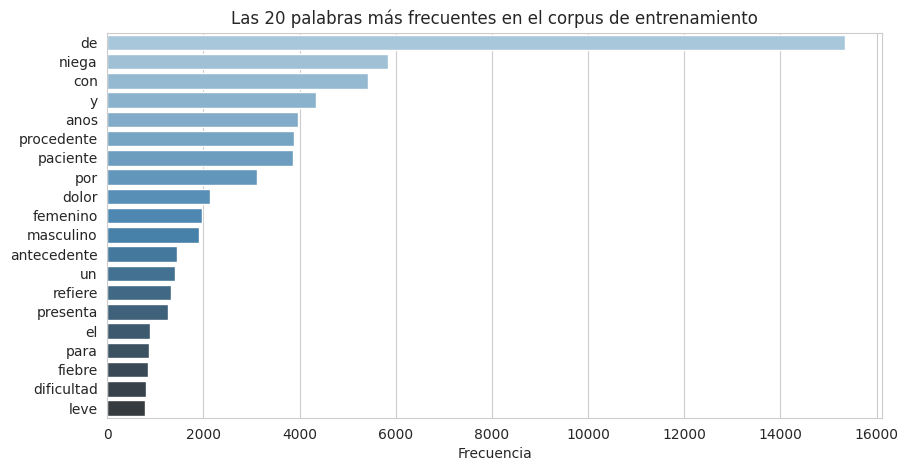

In [ ]:
top20 = contador.most_common(20)
palabras, frecuencias = zip(*top20)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(frecuencias), y=list(palabras), hue=list(palabras), palette="Blues_d", legend=False)
plt.title("Las 20 palabras más frecuentes en el corpus de entrenamiento")
plt.xlabel("Frecuencia")
plt.show()

**Nota:** destaca la palabra **"niega"** entre las más frecuentes. En la redacción clínica es habitual registrar lo que el paciente **no** tiene, y eso es justamente lo que hace difícil el NLP médico: una palabra como "dolor" o "torácico" puede aparecer tanto afirmada como negada, con significados clínicos **opuestos**.

## 4. Convertir texto a secuencias numéricas (con padding y longitud real)

Cada nota se convierte en una lista de índices, rellenada con `<PAD>` hasta una longitud común. Además guardamos la **longitud real** de cada nota: así la LSTM podrá **ignorar el relleno** (en el 4a la red también procesaba los `<PAD>`, lo que añadía ruido; aquí lo evitamos con `pack_padded_sequence`).

In [ ]:
LONGITUD_MAXIMA = 60

def texto_a_secuencia(texto, vocabulario, longitud_maxima=LONGITUD_MAXIMA):
    indices = [vocabulario.get(t, vocabulario["<UNK>"]) for t in tokenizar(texto)][:longitud_maxima]
    longitud_real = len(indices)
    indices += [vocabulario["<PAD>"]] * (longitud_maxima - longitud_real)
    return indices, longitud_real

def codificar(textos):
    pares = [texto_a_secuencia(t, vocabulario) for t in textos]
    X = np.array([p[0] for p in pares])
    longitudes = np.array([p[1] for p in pares])
    return X, longitudes

X_train, len_train = codificar(textos_train)
X_test, len_test = codificar(textos_test)
y_train = np.array(etiquetas_train, dtype="float32")
y_test = np.array(etiquetas_test, dtype="float32")

n_truncadas = int(np.sum([len(tokenizar(t)) > LONGITUD_MAXIMA for t in textos_train]))
print("Forma de X_train:", X_train.shape)
print(f"Notas truncadas por superar {LONGITUD_MAXIMA} tokens: {n_truncadas}")
print("\nEjemplo de secuencia (primeros 25 índices):", X_train[0][:25])
print("Longitud real de esa nota:", len_train[0])

Forma de X_train: (4000, 60)
Notas truncadas por superar 60 tokens: 2

Ejemplo de secuencia (primeros 25 índices): [  8  12   2   6   4 324   2  74   7   2  37  24   9  75  41  60  56  38
  21   3  20  18  43 149 138]
Longitud real de esa nota: 45


## 5. Preparar `Dataset` y `DataLoader` de PyTorch

In [ ]:
class NotasDataset(Dataset):
    def __init__(self, X, longitudes, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.longitudes = torch.tensor(longitudes, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.longitudes[idx], self.y[idx]

loader_train = DataLoader(NotasDataset(X_train, len_train, y_train), batch_size=32, shuffle=True)
loader_test = DataLoader(NotasDataset(X_test, len_test, y_test), batch_size=64, shuffle=False)
print("Lotes de entrenamiento:", len(loader_train))

Lotes de entrenamiento: 125


## 6. Construir la LSTM

Misma idea que en el 4a: **Embedding** (vector denso por palabra) → **LSTM** (lee la nota palabra por palabra y mantiene una memoria) → **Linear** (probabilidad de urgencia).

La diferencia clave es `pack_padded_sequence`: le dice a la LSTM dónde termina cada nota para que **no procese el relleno**. El estado oculto final resume la nota completa — incluyendo **qué síntomas fueron afirmados y cuáles negados**, porque la LSTM lee en orden.

In [ ]:
class LSTMTriaje(nn.Module):
    def __init__(self, tam_vocabulario, dim_embedding=32, unidades_lstm=64):
        super().__init__()
        self.embedding = nn.Embedding(tam_vocabulario, dim_embedding, padding_idx=0)
        self.lstm = nn.LSTM(dim_embedding, unidades_lstm, batch_first=True)
        self.salida = nn.Linear(unidades_lstm, 1)

    def forward(self, x, longitudes):
        embebido = self.embedding(x)                                   # (lote, longitud, dim_embedding)
        empaquetado = pack_padded_sequence(embebido, longitudes.cpu(),
                                           batch_first=True, enforce_sorted=False)
        _, (h_final, _) = self.lstm(empaquetado)                       # h_final: (1, lote, unidades_lstm)
        return self.salida(h_final.squeeze(0)).squeeze(1)              # un logit por nota

modelo = LSTMTriaje(tam_vocabulario=len(vocabulario)).to(dispositivo)
print(modelo)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo.parameters()):,}")

LSTMTriaje(
  (embedding): Embedding(837, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (salida): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros totales: 51,937


## 7. Entrenar (bucle manual) y vigilar el *recall*

Además de la pérdida y la exactitud, registramos el **recall de la clase urgente**: de todas las urgencias reales, ¿qué fracción detecta el modelo? En triaje, **es la métrica que más nos importa**, porque un falso negativo (una urgencia que pasa desapercibida) puede costar una vida, mientras que un falso positivo (una falsa alarma) solo cuesta tiempo de revisión.

In [ ]:
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)

def evaluar(modelo, loader):
    modelo.eval()
    correctos, total, perdida_total = 0, 0, 0.0
    verdaderos_positivos, positivos_reales = 0, 0
    with torch.no_grad():
        for X_lote, len_lote, y_lote in loader:
            X_lote, y_lote = X_lote.to(dispositivo), y_lote.to(dispositivo)
            logits = modelo(X_lote, len_lote)
            perdida_total += funcion_perdida(logits, y_lote).item() * len(y_lote)
            predicciones = (torch.sigmoid(logits) > 0.5).float()
            correctos += (predicciones == y_lote).sum().item()
            verdaderos_positivos += ((predicciones == 1) & (y_lote == 1)).sum().item()
            positivos_reales += (y_lote == 1).sum().item()
            total += len(y_lote)
    return perdida_total / total, correctos / total, verdaderos_positivos / positivos_reales

N_EPOCAS = 12
historial = {k: [] for k in ["perdida_train", "exactitud_train", "perdida_val", "exactitud_val", "recall_val"]}

for epoca in range(N_EPOCAS):
    modelo.train()
    for X_lote, len_lote, y_lote in loader_train:
        X_lote, y_lote = X_lote.to(dispositivo), y_lote.to(dispositivo)
        optimizador.zero_grad()
        perdida = funcion_perdida(modelo(X_lote, len_lote), y_lote)
        perdida.backward()
        optimizador.step()

    p_tr, a_tr, _ = evaluar(modelo, loader_train)
    p_va, a_va, r_va = evaluar(modelo, loader_test)
    for clave, valor in zip(historial, [p_tr, a_tr, p_va, a_va, r_va]):
        historial[clave].append(valor)
    print(f"Época {epoca + 1:2d}/{N_EPOCAS} | pérdida prueba: {p_va:.4f} | exactitud prueba: {a_va:.3f} | recall urgentes: {r_va:.3f}")

Época  1/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.718
Época  2/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.718
Época  3/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.718
Época  4/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.447 | recall urgentes: 0.715
Época  5/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.447 | recall urgentes: 0.715
Época  6/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.715
Época  7/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.715
Época  8/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.715
Época  9/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.715
Época 10/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.715
Época 11/12 | pérdida prueba: 0.6950 | exactitud prueba: 0.448 | recall urgentes: 0.715
Época 12/12 | pérdida prueba: 0.

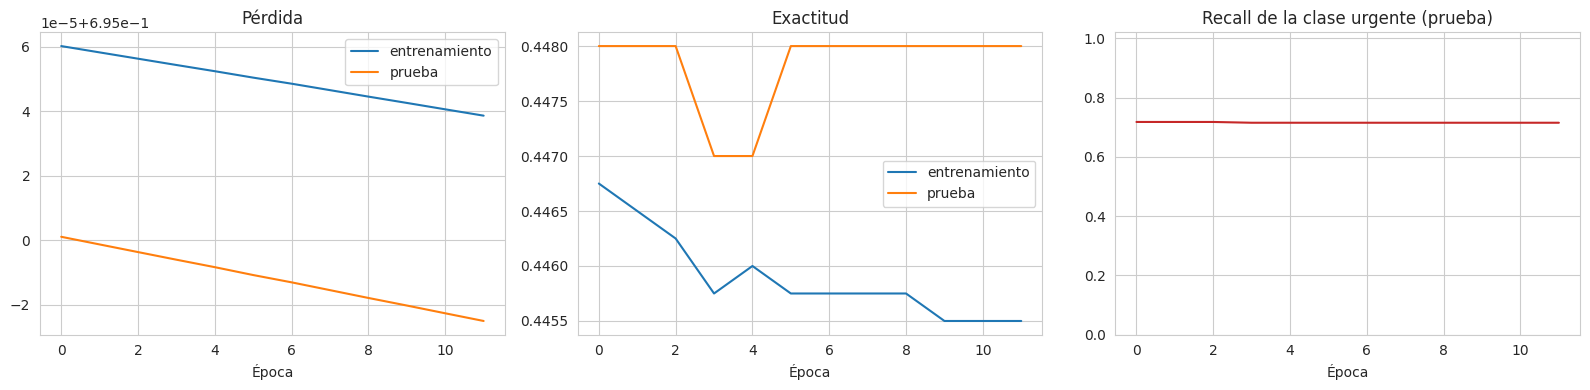

In [ ]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4))
ejes[0].plot(historial["perdida_train"], label="entrenamiento")
ejes[0].plot(historial["perdida_val"], label="prueba")
ejes[0].set_title("Pérdida"); ejes[0].set_xlabel("Época"); ejes[0].legend()
ejes[1].plot(historial["exactitud_train"], label="entrenamiento")
ejes[1].plot(historial["exactitud_val"], label="prueba")
ejes[1].set_title("Exactitud"); ejes[1].set_xlabel("Época"); ejes[1].legend()
ejes[2].plot(historial["recall_val"], color="#C62828")
ejes[2].set_title("Recall de la clase urgente (prueba)"); ejes[2].set_xlabel("Época")
ejes[2].set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 8. Evaluación: matriz de confusión e informe por clase

Aplicamos lo aprendido en la Semana 6: no basta la exactitud; miramos la **matriz de confusión** y la **precisión, recall y F1 por clase**.

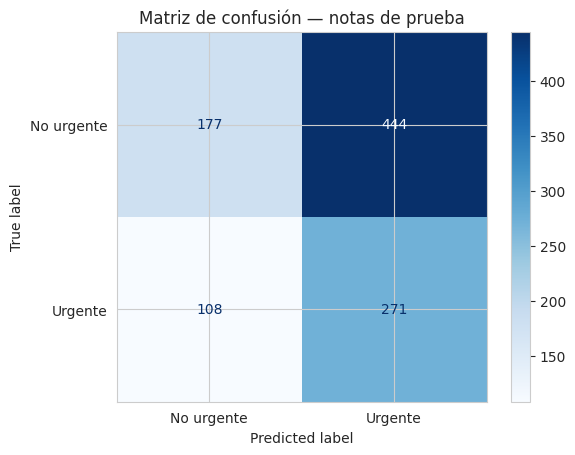

              precision    recall  f1-score   support

  No urgente      0.621     0.285     0.391       621
     Urgente      0.379     0.715     0.495       379

    accuracy                          0.448      1000
   macro avg      0.500     0.500     0.443      1000
weighted avg      0.529     0.448     0.430      1000

Falsos negativos (urgencias NO detectadas): 108 de 379


In [ ]:
def predecir_logits(textos, modelo=modelo):
    X, longitudes = codificar(textos)
    modelo.eval()
    with torch.no_grad():
        logits = modelo(torch.tensor(X, dtype=torch.long).to(dispositivo), torch.tensor(longitudes))
    return logits.cpu().numpy()

def predecir_probabilidades(textos, modelo=modelo):
    return 1 / (1 + np.exp(-predecir_logits(textos, modelo)))      # sigmoide: puntuación -> probabilidad

prob_test = predecir_probabilidades(textos_test)
pred_test = (prob_test > 0.5).astype(int)

ConfusionMatrixDisplay(confusion_matrix(etiquetas_test, pred_test),
                       display_labels=["No urgente", "Urgente"]).plot(cmap="Blues")
plt.title("Matriz de confusión — notas de prueba")
plt.show()

print(classification_report(etiquetas_test, pred_test, target_names=["No urgente", "Urgente"], digits=3))
falsos_negativos = int(np.sum((pred_test == 0) & (np.array(etiquetas_test) == 1)))
print(f"Falsos negativos (urgencias NO detectadas): {falsos_negativos} de {int(np.sum(etiquetas_test))}")

**Lectura:** el modelo obtiene un desempeño muy alto en el conjunto de prueba. **Cuidado:** esto se debe en parte a que los datos son sintéticos y sencillos; con notas clínicas reales el desempeño sería menor. Lo importante de esta sección no es el número, sino **cómo se mide** y, sobre todo, la prueba de la siguiente sección, que revela algo que este número oculta.

## 9. Prueba de comportamiento: ¿maneja la negación? (pares mínimos)

Un buen resultado en el conjunto de prueba **no garantiza** que el modelo haya entendido el lenguaje. Para comprobarlo, usamos **pares mínimos**: dos notas con **exactamente las mismas palabras**, pero donde cambia **qué síntoma está negado**:

- Nota A: *"Acude por **dolor torácico**. Niega **tos leve**."* → **urgente**
- Nota B: *"Acude por **tos leve**. Niega **dolor torácico**."* → **no urgente**

Un modelo de **bolsa de palabras** (que cuenta palabras sin importar el orden) ve **lo mismo** en ambas notas y no puede distinguirlas. Una **LSTM**, que lee en orden, sí puede. Entrenamos un clasificador de bolsa de palabras (TF-IDF + regresión logística) con los mismos datos para comparar.

In [ ]:
def pares_minimos(n=200, semilla=123):
    """Pares con las MISMAS palabras pero distinta urgencia, según qué síntoma se niega."""
    r = random.Random(semilla)
    textos, etiquetas = [], []
    for _ in range(n):
        u = r.choice([c for c, _ in URGENTES.values()])
        m = r.choice([c for c, _ in LEVES.values()])
        textos.append(f"Paciente de 40 años. Acude por {u}. Niega {m}."); etiquetas.append(1)
        textos.append(f"Paciente de 40 años. Acude por {m}. Niega {u}."); etiquetas.append(0)
    return textos, etiquetas


Bolsa de palabras  | Notas de prueba           | exactitud = 0.982
Bolsa de palabras  | Pares mínimos (negación)  | exactitud = 0.500
LSTM               | Notas de prueba           | exactitud = 0.448
LSTM               | Pares mínimos (negación)  | exactitud = 0.627


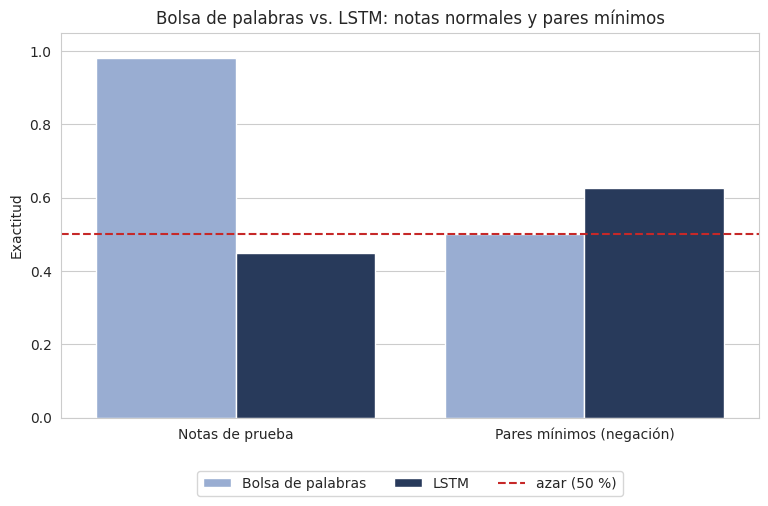

In [ ]:
textos_pares, etiquetas_pares = pares_minimos(n=200)

# Baseline: bolsa de palabras (ignora el orden)
vectorizador = TfidfVectorizer(tokenizer=tokenizar, lowercase=False, token_pattern=None)
baseline = LogisticRegression(max_iter=1000).fit(vectorizador.fit_transform(textos_train), etiquetas_train)

def exactitud(pred, reales):
    return float(np.mean(np.array(pred) == np.array(reales)))

resultados = {
    ("Bolsa de palabras", "Notas de prueba"): exactitud(baseline.predict(vectorizador.transform(textos_test)), etiquetas_test),
    ("Bolsa de palabras", "Pares mínimos (negación)"): exactitud(baseline.predict(vectorizador.transform(textos_pares)), etiquetas_pares),
    ("LSTM", "Notas de prueba"): exactitud(predecir_probabilidades(textos_test) > 0.5, etiquetas_test),
    ("LSTM", "Pares mínimos (negación)"): exactitud(predecir_probabilidades(textos_pares) > 0.5, etiquetas_pares),
}
for (modelo_nombre, prueba), valor in resultados.items():
    print(f"{modelo_nombre:18s} | {prueba:25s} | exactitud = {valor:.3f}")

filas = [(m, p, v) for (m, p), v in resultados.items()]
plt.figure(figsize=(9, 5))
sns.barplot(x=[f[1] for f in filas], y=[f[2] for f in filas], hue=[f[0] for f in filas],
            palette=["#8FAADC", "#1F3864"])
plt.axhline(0.5, color="#C62828", linestyle="--", label="azar (50 %)")
plt.ylim(0, 1.05); plt.ylabel("Exactitud"); plt.xlabel("")
plt.title("Bolsa de palabras vs. LSTM: notas normales y pares mínimos")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.show()

In [ ]:
# Un par concreto: mismas palabras, distinto significado clínico
par = ["Paciente de 40 años. Acude por convulsiones. Niega tos leve.",
       "Paciente de 40 años. Acude por tos leve. Niega convulsiones."]
prob_lstm = predecir_probabilidades(par)
prob_bolsa = baseline.predict_proba(vectorizador.transform(par))[:, 1]
for nota, pl, pb in zip(par, prob_lstm, prob_bolsa):
    print(nota)
    print(f"   P(urgente) LSTM = {pl:.3f}  |  P(urgente) bolsa de palabras = {pb:.3f}\n")

Paciente de 40 años. Acude por convulsiones. Niega tos leve.
   P(urgente) LSTM = 0.513  |  P(urgente) bolsa de palabras = 0.103

Paciente de 40 años. Acude por tos leve. Niega convulsiones.
   P(urgente) LSTM = 0.513  |  P(urgente) bolsa de palabras = 0.103



### ¿Y si la negación se redacta de otra forma?

Los pares mínimos de arriba siempre usan la estructura "*Acude por X. Niega Y.*". Para saber si la LSTM solo memorizó esa forma, probamos **otras estructuras** (la negación dentro de la misma oración, antes del motivo, con otras fórmulas como "descarta" o "ausencia de"), siempre con los mismos síntomas ya conocidos.

In [ ]:
def pares_con_estructura(plantilla, n=200, semilla=11):
    r = random.Random(semilla)
    textos, etiquetas = [], []
    for _ in range(n):
        u = r.choice([c for c, _ in URGENTES.values()])
        m = r.choice([c for c, _ in LEVES.values()])
        textos.append(plantilla.format(a=u, b=m)); etiquetas.append(1)   # urgente AFIRMADO
        textos.append(plantilla.format(a=m, b=u)); etiquetas.append(0)   # urgente NEGADO
    return textos, etiquetas

estructuras = {
    "Misma oración, con 'sin'": "Paciente de 40 años. Acude por {a} sin {b}.",
    "Misma oración, con 'niega'": "Paciente de 40 años. Acude por {a} y niega {b}.",
    "Negación antes del motivo": "Paciente de 40 años. Niega {b}. Acude por {a}.",
    "Fórmula 'no tiene'": "Paciente de 40 años. Acude por {a}. No tiene {b}.",
    "Fórmula 'descarta'": "Paciente de 40 años que acude por {a}, descarta {b}.",
    "'Ausencia de' al inicio": "Ausencia de {b} en paciente de 40 años. Acude por {a}.",
}
print(f"{'Estructura de la negación':30s} | {'LSTM':>6s} | {'Bolsa de palabras':>17s}")
for nombre, plantilla in estructuras.items():
    t, e = pares_con_estructura(plantilla)
    acc_lstm = exactitud(predecir_probabilidades(t) > 0.5, e)
    acc_bolsa = exactitud(baseline.predict(vectorizador.transform(t)), e)
    print(f"{nombre:30s} | {acc_lstm:6.2f} | {acc_bolsa:17.2f}")

Estructura de la negación      |   LSTM | Bolsa de palabras
Misma oración, con 'sin'       |   0.59 |              0.50
Misma oración, con 'niega'     |   0.58 |              0.50
Negación antes del motivo      |   0.41 |              0.50
Fórmula 'no tiene'             |   0.57 |              0.50
Fórmula 'descarta'             |   0.58 |              0.50
'Ausencia de' al inicio        |   0.43 |              0.50


**Lectura:** ambos modelos aciertan casi todo en las notas de prueba, pero en los **pares mínimos** la bolsa de palabras queda en torno al **azar** (50 %), porque literalmente no puede distinguir las dos notas. La LSTM mantiene un desempeño muy superior, incluso con estructuras que no vio de forma idéntica en el entrenamiento, porque **procesa la secuencia** y puede usar el orden y el papel de cada frase (qué se afirma como motivo y qué se niega). **Ojo:** esto no prueba que haya "entendido" la negación en general; las secciones 11 y 13 muestran sus límites reales.

Esta es una técnica de evaluación general (*behavioral testing*): además del conjunto de prueba habitual, diseñar **casos que ponen a prueba una capacidad concreta** (negación, abreviaturas, erratas…). En medicina, donde confundir "tiene" con "no tiene" es grave, es indispensable.

## 10. El umbral de decisión y el costo clínico de los errores

Por defecto el modelo dice "urgente" si la probabilidad supera **0.5**. Pero ese umbral es una **decisión de diseño**, no una ley. Si no detectar una urgencia es mucho peor que una falsa alarma, conviene **bajar el umbral**: así se detectan más urgencias (menos falsos negativos) a costa de más falsas alarmas (falsos positivos) — el mismo compromiso estudiado en la Semana 6.

Contamos, para cada umbral, cuántas **urgencias se nos escapan (FN)** y cuántas **falsas alarmas generamos (FP)** en las 1 000 notas de prueba.

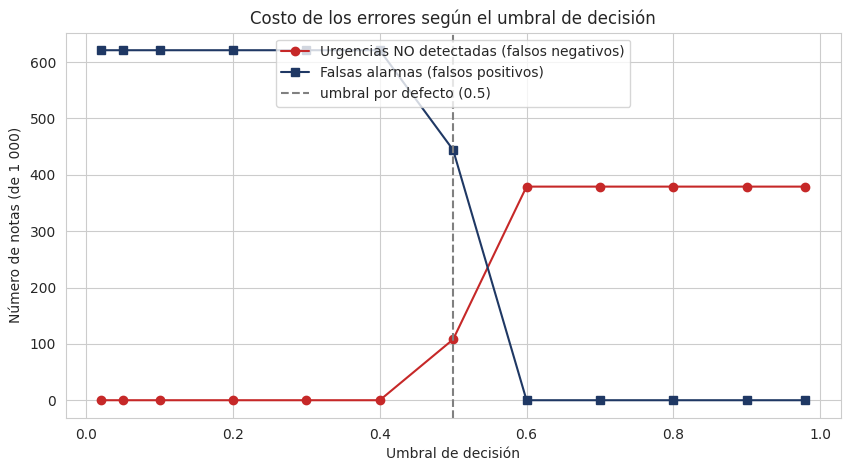

 Umbral |  FN |  FP | Recall | Precisión
   0.02 |   0 | 621 |  1.000 |     0.379
   0.05 |   0 | 621 |  1.000 |     0.379
   0.10 |   0 | 621 |  1.000 |     0.379
   0.20 |   0 | 621 |  1.000 |     0.379
   0.30 |   0 | 621 |  1.000 |     0.379
   0.40 |   0 | 621 |  1.000 |     0.379
   0.50 | 108 | 444 |  0.715 |     0.379
   0.60 | 379 |   0 |  0.000 |     0.000
   0.70 | 379 |   0 |  0.000 |     0.000
   0.80 | 379 |   0 |  0.000 |     0.000
   0.90 | 379 |   0 |  0.000 |     0.000
   0.98 | 379 |   0 |  0.000 |     0.000


In [ ]:
umbrales = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.98]
reales = np.array(etiquetas_test)

falsos_negativos_u, falsas_alarmas_u = [], []
for u in umbrales:
    pred = prob_test > u
    falsos_negativos_u.append(int(np.sum((~pred) & (reales == 1))))
    falsas_alarmas_u.append(int(np.sum(pred & (reales == 0))))

plt.figure(figsize=(10, 5))
plt.plot(umbrales, falsos_negativos_u, label="Urgencias NO detectadas (falsos negativos)", color="#C62828", marker="o")
plt.plot(umbrales, falsas_alarmas_u, label="Falsas alarmas (falsos positivos)", color="#1F3864", marker="s")
plt.axvline(0.5, color="gray", linestyle="--", label="umbral por defecto (0.5)")
plt.xlabel("Umbral de decisión"); plt.ylabel("Número de notas (de 1 000)")
plt.title("Costo de los errores según el umbral de decisión")
plt.legend(loc="upper center")
plt.show()

print(f"{'Umbral':>7s} | {'FN':>3s} | {'FP':>3s} | {'Recall':>6s} | {'Precisión':>9s}")
for u, fn, fp in zip(umbrales, falsos_negativos_u, falsas_alarmas_u):
    pred = prob_test > u
    print(f"{u:7.2f} | {fn:3d} | {fp:3d} | {recall_score(reales, pred):6.3f} | {precision_score(reales, pred, zero_division=0):9.3f}")

**Lectura:** observa cómo se mueven las dos curvas al bajar el umbral. En la ejecución de referencia, bajar mucho el umbral recupera **muy pocas urgencias adicionales**, pero **multiplica las falsas alarmas**: los errores que le quedan al modelo son "confiados" (da probabilidades altas a notas que no lo merecen o viceversa), y el umbral no puede corregirlos. Para reducirlos hay que mejorar **los datos y el modelo**, no solo el umbral.

**Para discutir en clase:** ¿qué umbral elegiría un servicio de emergencias? ¿Y un sistema que solo ordena la cola de revisión de un médico? La elección depende del **costo relativo** de cada error y de la **capacidad humana** para revisar las falsas alarmas. Un buen sistema clínico no reemplaza al profesional: **prioriza y avisa**, y la decisión final es humana (*human in the loop*).

## 11. Explicabilidad y pruebas contrafactuales: ¿en qué se fija el modelo?

En salud, un resultado sin explicación genera desconfianza. Veremos dos técnicas complementarias.

### 11.1 Oclusión: quitar palabras y medir el cambio

Quitamos cada palabra de la nota, una por una, y medimos **cuánto cambia la puntuación de urgencia**. (Usamos la **puntuación interna del modelo, antes de convertirla en probabilidad** — el *logit* —, porque cuando la probabilidad ya es casi 0 o casi 1 apenas se mueve y esconde los efectos.)

- Barras **rojas** (positivas): la palabra **empuja hacia "urgente"** (si la quitamos, la puntuación baja).
- Barras **azules** (negativas): la palabra **frena** la urgencia.

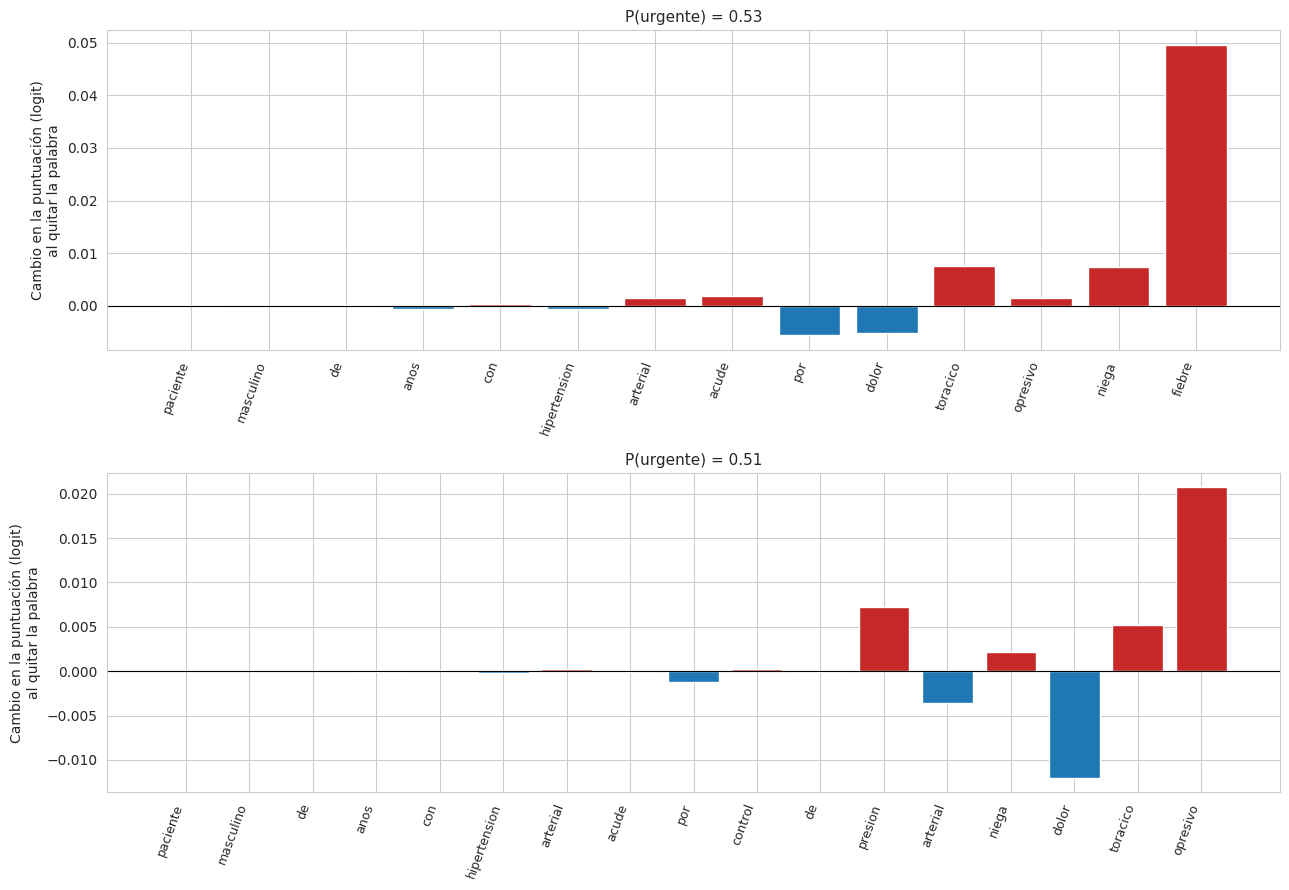

In [ ]:
def importancia_por_oclusion(nota):
    tokens = tokenizar(nota)
    logit_base = predecir_logits([nota])[0]
    logits_sin_palabra = predecir_logits([" ".join(tokens[:i] + tokens[i + 1:]) for i in range(len(tokens))])
    return tokens, 1 / (1 + np.exp(-logit_base)), logit_base - logits_sin_palabra

def graficar_oclusion(nota, ax):
    tokens, p_base, cambios = importancia_por_oclusion(nota)
    colores = ["#C62828" if c > 0 else "#1F77B4" for c in cambios]
    ax.bar(range(len(tokens)), cambios, color=colores)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=70, ha="right", fontsize=9)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"P(urgente) = {p_base:.2f}", fontsize=11)
    ax.set_ylabel("Cambio en la puntuación (logit)\nal quitar la palabra")

notas_explicar = [
    "Paciente masculino de 58 años con HTA. Acude por dolor torácico opresivo. Niega fiebre.",
    "Paciente masculino de 58 años con HTA. Acude por control de presión arterial. Niega dolor torácico opresivo.",
]
fig, ejes = plt.subplots(2, 1, figsize=(13, 9))
for nota, eje in zip(notas_explicar, ejes):
    graficar_oclusion(nota, eje)
plt.tight_layout()
plt.show()

**Lectura:** en la primera nota, la palabra **"toracico"** aporta con diferencia la mayor parte de la puntuación hacia *urgente*. En la segunda, ninguna palabra empuja con fuerza: el modelo está firmemente en *no urgente*.

Pero ojo: **la oclusión es solo una aproximación**. Al borrar una palabra se crea una frase antinatural (quitar "niega" deja *"control de presión arterial dolor torácico opresivo"*) y el modelo no reacciona como esperaríamos. Por eso conviene complementarla con una prueba más directa.

### 11.2 Pruebas contrafactuales: cambiar UNA palabra y ver qué pasa

En lugar de borrar, **cambiamos solo la palabra clave** (por ejemplo, "niega" por "refiere") y comprobamos si el modelo cambia su veredicto de la forma que lo haría una persona.

In [ ]:
pares_contrafactuales = [
    ("Paciente masculino de 58 años con HTA. Acude por control de presión arterial. Niega dolor torácico opresivo.",
     "Paciente masculino de 58 años con HTA. Acude por control de presión arterial. Refiere dolor torácico opresivo."),
    ("Paciente femenino de 30 años. Acude por tos leve. Niega convulsiones.",
     "Paciente femenino de 30 años. Acude por tos leve. Presenta convulsiones."),
    ("Paciente de 45 años. Acude por resfrío. Niega hemorragia abundante.",
     "Paciente de 45 años. Acude por resfrío. Tiene hemorragia abundante."),
    ("Paciente femenino de 30 años. Acude por convulsiones. Niega tos leve.",
     "Paciente femenino de 30 años. Acude por convulsiones. Refiere tos leve."),
]
print("Un clínico esperaría: en los 3 primeros pares la probabilidad DEBERÍA SUBIR (síntoma de alarma ahora afirmado);")
print("en el último, debería seguir ALTA (las convulsiones siguen siendo el motivo de consulta).\n")
for original, modificada in pares_contrafactuales:
    p_original, p_modificada = predecir_probabilidades([original, modificada])
    print(f"P(urgente): {p_original:.3f} -> {p_modificada:.3f}")
    print(f"     antes  : ...{original.split('. ')[-1]}")
    print(f"     después: ...{modificada.split('. ')[-1]}\n")

Un clínico esperaría: en los 3 primeros pares la probabilidad DEBERÍA SUBIR (síntoma de alarma ahora afirmado);
en el último, debería seguir ALTA (las convulsiones siguen siendo el motivo de consulta).

P(urgente): 0.512 -> 0.508
     antes  : ...Niega dolor torácico opresivo.
     después: ...Refiere dolor torácico opresivo.

P(urgente): 0.513 -> 0.497
     antes  : ...Niega convulsiones.
     después: ...Presenta convulsiones.

P(urgente): 0.487 -> 0.488
     antes  : ...Niega hemorragia abundante.
     después: ...Tiene hemorragia abundante.

P(urgente): 0.513 -> 0.504
     antes  : ...Niega tos leve.
     después: ...Refiere tos leve.



**Lectura (importante):** en la ejecución de referencia, **el modelo no reacciona como lo haría una persona**. En los primeros pares el síntoma de alarma pasa de *negado* a *afirmado*, y sin embargo la probabilidad de urgencia **casi no sube**. ¿Por qué si pasó los pares mínimos?

Porque en nuestros datos sintéticos **los síntomas de alarma afirmados siempre aparecen como motivo principal de consulta** ("*Acude por…*"), nunca como un segundo problema. El modelo no aprendió la regla general *"cualquier síntoma de alarma afirmado ⇒ urgente"*, sino un patrón más estrecho: **"la urgencia la define el motivo principal"**. Superó los pares mínimos porque allí el síntoma de alarma o es el motivo o está negado; el contrafactual encuentra el caso que **el diseño de los datos nunca incluyó**.

El **último par** muestra el reverso: la nota sigue teniendo una convulsión como motivo de consulta (debería seguir siendo urgente), pero al añadir una molestia leve *afirmada* la probabilidad **cae mucho**. El modelo se deja arrastrar por una frase que no debería cambiar el veredicto.

Moraleja para el NLP clínico: un buen resultado en las pruebas que *nosotros* diseñamos **no demuestra comprensión**. Hay que buscar activamente los casos que el modelo podría estar resolviendo con atajos — y, en un sistema real, hacerlo junto con **profesionales de la salud**, que conocen los casos difíciles que nosotros no imaginamos.

## 12. Visualizar el espacio de embeddings aprendido

Con PCA reducimos los vectores de 32 dimensiones a 2 para ver qué palabras quedaron "cerca". Marcamos en **rojo** términos de síntomas de alarma, en **verde** términos de consultas leves o de rutina, y en **gris** palabras funcionales (incluida la negación).

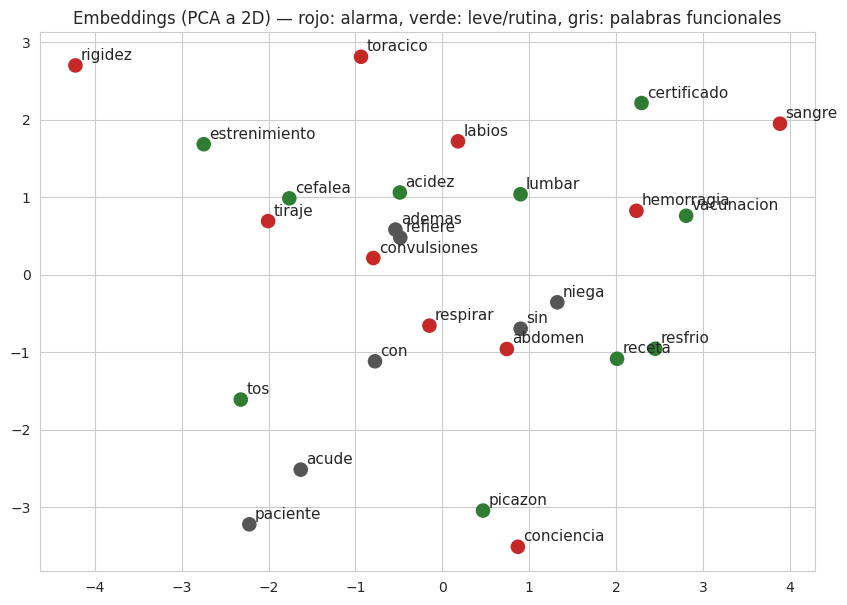

In [ ]:
grupos = {
    "alarma": ["toracico", "convulsiones", "hemorragia", "sangre", "respirar", "conciencia",
               "tiraje", "rigidez", "abdomen", "labios"],
    "leve": ["tos", "receta", "acidez", "certificado", "resfrio", "vacunacion",
             "estrenimiento", "cefalea", "picazon", "lumbar"],
    "funcional": ["niega", "refiere", "acude", "paciente", "con", "sin", "ademas"],
}
palabras_validas, colores = [], []
for grupo, color in [("alarma", "#C62828"), ("leve", "#2E7D32"), ("funcional", "#555555")]:
    for p in grupos[grupo]:
        if p in vocabulario:
            palabras_validas.append(p); colores.append(color)

vectores = modelo.embedding.weight.detach().cpu().numpy()[[vocabulario[p] for p in palabras_validas]]
coordenadas = PCA(n_components=2).fit_transform(vectores)

plt.figure(figsize=(10, 7))
plt.scatter(coordenadas[:, 0], coordenadas[:, 1], c=colores, s=90)
for (x, y), palabra in zip(coordenadas, palabras_validas):
    plt.annotate(palabra, (x, y), fontsize=11, xytext=(4, 4), textcoords="offset points")
plt.title("Embeddings (PCA a 2D) — rojo: alarma, verde: leve/rutina, gris: palabras funcionales")
plt.show()

**Lectura:** a diferencia de lo que vimos con las reseñas de películas en el 4a, aquí **no se observan grupos limpios**: las palabras de alarma y de rutina aparecen mezcladas. No es un error: (1) PCA a 2 dimensiones **pierde mucha información** de los 32 originales; (2) con un corpus pequeño y sintético, los embeddings aprendidos **no necesitan** separar las palabras por "gravedad", porque la LSTM combina la información de toda la nota; y (3) la similitud entre palabras en un embedding entrenado desde cero con poco texto es **difícil de interpretar**.

Por eso, en el NLP biomédico real se parte de **embeddings preentrenados con millones de documentos** (y no de cero), y se interpreta el resultado con prudencia: **que una figura se vea bonita o desordenada no demuestra por sí solo que el modelo funcione o falle**.

## 13. Lo que el modelo NO sabe: el peligro del exceso de confianza

Hasta ahora todas las notas usaban vocabulario y frases parecidas a las del entrenamiento. ¿Qué pasa cuando llega una nota **con palabras que el modelo nunca vio**? Probamos con consultas **claramente benignas** pero de temas ausentes del corpus (ninguna menciona un síntoma de alarma) y con **texto sin sentido**.

P(urgente) = 0.506 | Paciente de 28 años con dolor de oído leve desde ayer.
      términos que el modelo no conoce: ['oido']
P(urgente) = 0.502 | Paciente de 19 años que consulta por uñas quebradizas.
      términos que el modelo no conoce: ['unas', 'quebradizas']
P(urgente) = 0.505 | Paciente de 50 años con callos en los pies.
      términos que el modelo no conoce: ['callos', 'los', 'pies']
P(urgente) = 0.504 | Paciente de 33 años que solicita revisión de lentes.
      términos que el modelo no conoce: ['solicita', 'lentes']
P(urgente) = 0.495 | Paciente de 41 años con caída del cabello de varios meses.
      términos que el modelo no conoce: ['caida', 'cabello', 'meses']
P(urgente) = 0.500 | Paciente de 24 años con revisión dental de rutina.
      términos que el modelo no conoce: ['dental']
P(urgente) = 0.489 | Paciente de 36 años con picadura de mosquito en el brazo.
      términos que el modelo no conoce: ['picadura', 'mosquito']
P(urgente) = 0.504 | xqz plm wvb trk
      término

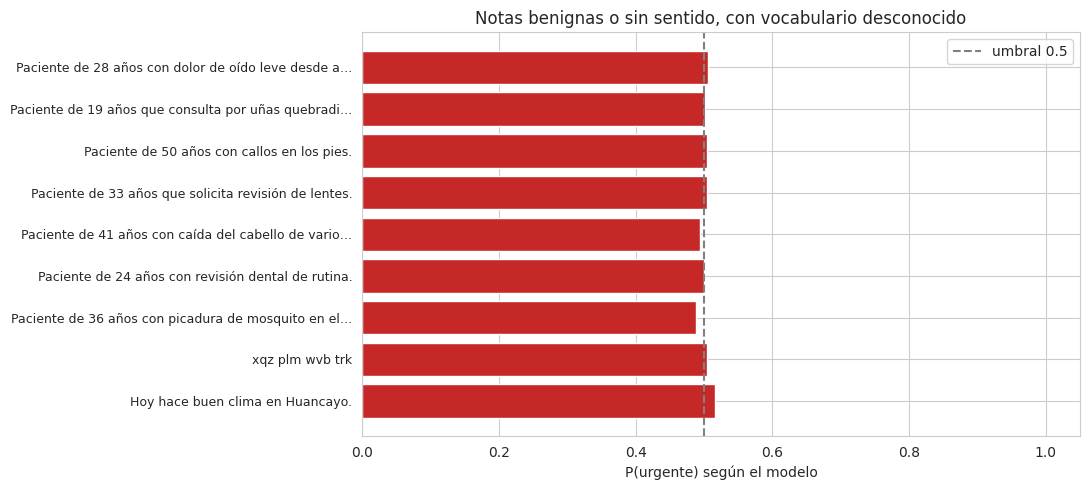

In [ ]:
notas_desconocidas = [
    "Paciente de 28 años con dolor de oído leve desde ayer.",
    "Paciente de 19 años que consulta por uñas quebradizas.",
    "Paciente de 50 años con callos en los pies.",
    "Paciente de 33 años que solicita revisión de lentes.",
    "Paciente de 41 años con caída del cabello de varios meses.",
    "Paciente de 24 años con revisión dental de rutina.",
    "Paciente de 36 años con picadura de mosquito en el brazo.",
    "xqz plm wvb trk",
    "Hoy hace buen clima en Huancayo.",
]
prob_desconocidas = predecir_probabilidades(notas_desconocidas)

def terminos_desconocidos(nota):
    return [t for t in tokenizar(nota) if t not in vocabulario]

for nota, p in zip(notas_desconocidas, prob_desconocidas):
    print(f"P(urgente) = {p:.3f} | {nota}")
    print(f"      términos que el modelo no conoce: {terminos_desconocidos(nota)}")

etiquetas_barras = [n if len(n) <= 52 else n[:50] + "…" for n in notas_desconocidas]
plt.figure(figsize=(11, 5))
plt.barh(range(len(notas_desconocidas)), prob_desconocidas, color="#C62828")
plt.yticks(range(len(notas_desconocidas)), etiquetas_barras, fontsize=9)
plt.axvline(0.5, color="gray", linestyle="--", label="umbral 0.5")
plt.gca().invert_yaxis()
plt.xlim(0, 1.05); plt.xlabel("P(urgente) según el modelo")
plt.title("Notas benignas o sin sentido, con vocabulario desconocido")
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** en la ejecución de referencia, el modelo asigna una probabilidad **alta de urgencia** a prácticamente todas estas notas — **incluso al texto sin sentido**. ¿Por qué? Porque en nuestros datos toda consulta de rutina usa una de unas pocas frases conocidas, y el modelo aprendió un **atajo** (*shortcut learning*): *"si no reconozco una consulta leve, la trato como urgente"*. Nunca se le enseñó a decir **"no sé"**.

Es una de las lecciones más importantes del NLP clínico:
- Una **probabilidad alta no significa que el modelo entienda**: puede estar muy seguro y totalmente equivocado.
- Los datos de entrenamiento deben **cubrir la variedad real** de lo que llegará en producción.
- Todo sistema necesita un mecanismo para detectar cuándo una entrada **cae fuera de lo que conoce**.

Una salvaguarda sencilla (aunque no perfecta) es contar los **términos desconocidos**: si la nota contiene palabras fuera del vocabulario, el sistema debe responder **"no concluyente → revisión humana"** en lugar de dar una probabilidad en la que no deberíamos confiar. Veamos con qué frecuencia se activaría en las notas de prueba normales.

In [ ]:
def tiene_terminos_desconocidos(nota):
    return len(terminos_desconocidos(re.sub(r"\[[^\]]+\]", " ", nota))) > 0   # se ignoran marcas como [DNI]

marcadas_prueba = np.mean([tiene_terminos_desconocidos(t) for t in textos_test])
marcadas_desconocidas = np.mean([tiene_terminos_desconocidos(t) for t in notas_desconocidas])
print(f"Notas de prueba normales marcadas como 'no concluyentes': {marcadas_prueba:.1%}  (errores de tipeo nuevos)")
print(f"Notas con vocabulario desconocido marcadas como 'no concluyentes': {marcadas_desconocidas:.1%}")

Notas de prueba normales marcadas como 'no concluyentes': 4.8%  (errores de tipeo nuevos)
Notas con vocabulario desconocido marcadas como 'no concluyentes': 100.0%


**Lectura:** la salvaguarda deja pasar la gran mayoría de las notas normales y marca casi todas las que traen vocabulario nuevo. Es un **detector de entradas fuera de dominio muy básico**; en sistemas reales se usan técnicas más finas (calibración de probabilidades, estimación de incertidumbre, modelos que pueden abstenerse), pero el principio es el mismo: **un sistema clínico debe saber cuándo no debe opinar**.

## 14. Probar con tus propias notas (flujo completo: privacidad → análisis con salvaguarda)

Unimos todo en una función que **anonimiza** la nota, revisa si contiene **términos desconocidos** y, si no, **estima la urgencia**. Prueba tus propias notas: con negaciones, abreviaturas, erratas o sin tildes.

In [ ]:
def analizar_nota(nota, umbral=0.5):
    nota_anonima = anonimizar(nota)
    probabilidad = float(predecir_probabilidades([nota_anonima])[0])
    desconocidos = terminos_desconocidos(re.sub(r"\[[^\]]+\]", " ", nota_anonima))
    if desconocidos:
        veredicto = f"⚠️ NO CONCLUYENTE (términos desconocidos: {desconocidos}) -> revisión humana"
    elif probabilidad > umbral:
        veredicto = "🔴 REVISAR CON URGENCIA"
    else:
        veredicto = "🟢 NO URGENTE"
    print(f"Nota (anonimizada): {nota_anonima}")
    print(f"   -> P(urgente) = {probabilidad:.3f}  {veredicto}\n")

notas_propias = [
    "Pte femenino de 67 años c/ HTA, procedente de Huancayo. Refiere perdida de conciencia seguida de confusion.",
    "Paciente masculino de 25 años. Consulta por resfrío tras las heladas. Niega dificultad para respirar.",
    "Niña de 4 años con tiraje subcostal y respiración muy rápida. Niega fiebre.",
    "Paciente: Ana Torres Rojas, DNI 87654321. Acude por renovacion de receta. Niega dolor toracico.",
    "Paciente masculino de 40 años. Refiere dolor toraxico opresivo que se irradia al brazo izquierdo.",
    "Paciente femenino de 30 años. Control de niño sano y vacunación. Estado de ánimo conservado.",
]
for nota in notas_propias:
    analizar_nota(nota)

Nota (anonimizada): Pte femenino de 67 años c/ HTA, procedente de Huancayo. Refiere perdida de conciencia seguida de confusion.
   -> P(urgente) = 0.513  🔴 REVISAR CON URGENCIA

Nota (anonimizada): Paciente masculino de 25 años. Consulta por resfrío tras las heladas. Niega dificultad para respirar.
   -> P(urgente) = 0.516  🔴 REVISAR CON URGENCIA

Nota (anonimizada): Niña de 4 años con tiraje subcostal y respiración muy rápida. Niega fiebre.
   -> P(urgente) = 0.526  ⚠️ NO CONCLUYENTE (términos desconocidos: ['nina']) -> revisión humana

Nota (anonimizada): Paciente: [NOMBRE], [DNI]. Acude por renovacion de receta. Niega dolor toracico.
   -> P(urgente) = 0.505  🔴 REVISAR CON URGENCIA

Nota (anonimizada): Paciente masculino de 40 años. Refiere dolor toraxico opresivo que se irradia al brazo izquierdo.
   -> P(urgente) = 0.493  ⚠️ NO CONCLUYENTE (términos desconocidos: ['toraxico']) -> revisión humana

Nota (anonimizada): Paciente femenino de 30 años. Control de niño sano y vacunación. 

**Observa:** ¿qué pasa con la nota que tiene la errata "toraxico" y con la de la niña ("niña" no aparece en el entrenamiento)? El sistema las marca como **no concluyentes** y deja la decisión a una persona, en lugar de arriesgarse con una probabilidad poco fiable. Ese comportamiento prudente es preferible a una respuesta segura pero equivocada.



## 15. Limitaciones y ética: de este ejercicio a un sistema clínico real

Este notebook muestra **cómo funciona la técnica**, pero hay una gran distancia entre un ejercicio y un sistema clínico. Lo que faltaría:

| Aspecto | Lo que hicimos aquí | Lo que exige un sistema real |
|---|---|---|
| **Datos** | Notas sintéticas, generadas con plantillas | Notas clínicas reales, **revisadas y etiquetadas por profesionales de la salud** (con acuerdo entre anotadores) |
| **Privacidad** | Datos inventados + regex de ejemplo | Autorización, comité de ética, de-identificación rigurosa (NER + revisión humana), cumplimiento de la **Ley N.º 29733** |
| **Cobertura** | Una decena de síntomas y frases fijas | Miles de formas de redactar, jerga local, idiomas (español, quechua), notas largas y desordenadas |
| **Evaluación** | Un conjunto de prueba sintético | Validación **externa y prospectiva**, en distintos centros y poblaciones, con análisis de errores por subgrupo (edad, sexo, procedencia) |
| **Sesgos** | No analizados | Auditoría de sesgos: un modelo puede funcionar peor para grupos poco representados en los datos |
| **Uso** | Demostración educativa | **Apoyo a la decisión**, nunca reemplazo del criterio clínico; con responsabilidad definida y trazabilidad |

**Datos y modelos reales para seguir explorando** (verifica en cada caso las condiciones de acceso y de uso): corpus biomédicos públicos de resúmenes científicos (PubMed), bases de notas clínicas de acceso restringido y bajo credenciales (por ejemplo, MIMIC en PhysioNet) y modelos de lenguaje preentrenados en texto biomédico, que se pueden ajustar (*fine-tuning*) con muy pocos datos etiquetados — tema relacionado con el *transfer learning* de los notebooks 3a y 3b.

## 16. Resumen

- El flujo de NLP es el mismo del 4a (normalizar → tokenizar → vocabulario → padding → embedding → LSTM), pero el **texto médico** exige cuidados adicionales: **privacidad**, **abreviaturas y erratas**, **números** y, sobre todo, **negación**.
- Con `pack_padded_sequence` la LSTM **ignora el relleno** y resume cada nota en su estado final.
- Un buen resultado en el conjunto de prueba **no demuestra comprensión**: los **pares mínimos** mostraron que una bolsa de palabras ignora la negación y una LSTM sí usa el orden; pero las **pruebas contrafactuales** revelaron que la LSTM se apoyaba en un patrón estrecho de los datos ("la urgencia la define el motivo principal"), no en una regla general.
- En salud el costo de los errores es asimétrico: se prioriza el **recall** de las urgencias y se ajusta el **umbral** de decisión (Semana 6).
- La **explicabilidad** (oclusión) ayuda a verificar en qué se basa el modelo — indispensable para la confianza del personal de salud.
- **Una probabilidad alta no es comprensión:** ante vocabulario desconocido el modelo respondió con mucha seguridad y sin fundamento. Hay que **cubrir la variedad real** en los datos y **detectar las entradas fuera de dominio** para derivarlas a una persona.
- Todo sistema de este tipo es **apoyo a la decisión**, con supervisión humana, validación rigurosa y protección de los datos.

### Retos propuestos
1. Agrega una tercera clase ("moderada") al generador y adapta el modelo a 3 clases (usa `CrossEntropyLoss`).
2. Cambia la `LSTM` por una **bidireccional** (`bidirectional=True`) y compara su desempeño en los pares mínimos.
3. Amplía `EXPANSION_ABREVIATURAS` y mide si mejora la robustez ante abreviaturas nuevas.
4. Añade al generador la negación con otras fórmulas ("sin evidencia de…", "descarta…", "no presenta…") y comprueba si el modelo las generaliza.
5. Genera menos notas de entrenamiento (por ejemplo, `generar_dataset(500, ...)`) y observa qué pasa con el recall y con los pares mínimos.
6. Modifica el generador para que a veces aparezca un síntoma de alarma **afirmado como problema secundario** ("Además refiere dolor torácico…") y vuelve a ejecutar las pruebas contrafactuales de la sección 11.2: ¿corrige el modelo su error?
7. Agrega al generador **más tipos de consulta leve** (oído, dental, piel, oftalmología…) y comprueba si desaparece el atajo de la sección 13. ¿Qué pasa ahora con el texto sin sentido?